## Installing the Dependencies/Libraries

In [ ]:
# Install required libraries, including Seaborn for enhanced visualizations
!pip install numpy==1.26.4 pandas==2.2.0 matplotlib==3.8.3 scikit-learn==1.4.1.post1 seaborn==0.13.2

## Import Libraries

In [1]:
# Import libraries for data analysis, machine learning, and visualization
# NumPy: Handles arrays and numerical operations
# Pandas: Manages data in tabular form (e.g., loading CSV)
# Matplotlib: Base plotting library (used with Seaborn)
# Seaborn: Creates beautiful, statistical visualizations
# Scikit-learn: Provides tools for scaling, splitting, modeling, and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')  # Prevents clutter from warning messages
%matplotlib inline 

## Load Dataset

In [2]:
# Load the crop recommendation dataset from a CSV file
# Contains features (N, P, K, temperature, humidity, pH, rainfall) and target (crop labels)
crop = pd.read_csv("./data/crop_recommendation.csv")
crop.head()  # Preview the first 5 rows to verify data loading

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Check dataset Shape

In [3]:
# Display the dataset’s dimensions (rows, columns)
# Helps gauge the dataset size (e.g., 2200 rows, 8 columns)
crop.shape

(2200, 8)

## Check for Missing Values

In [4]:
# Check for missing values in each column
# Zero missing values confirm the dataset is complete and ready for use
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## Check for Duplicate Values

In [6]:
# Check for duplicate rows
# No duplicates ensure each data point is unique
crop.duplicated().sum()

0

## Dataset info

In [7]:
# Show column data types and non-null counts
# Confirms features are numeric (float/int) and target is categorical (object)
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## Check Unique Crop Names

In [8]:
# Count occurrences of each crop label
# Balanced counts (e.g., ~100 per crop) indicate a good dataset for classification
crop['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

## Summary Statistics

In [9]:
# Provide statistical overview (mean, std, min, max) of numerical features
# Useful for understanding data ranges and distributions
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## Visualization - Histogram

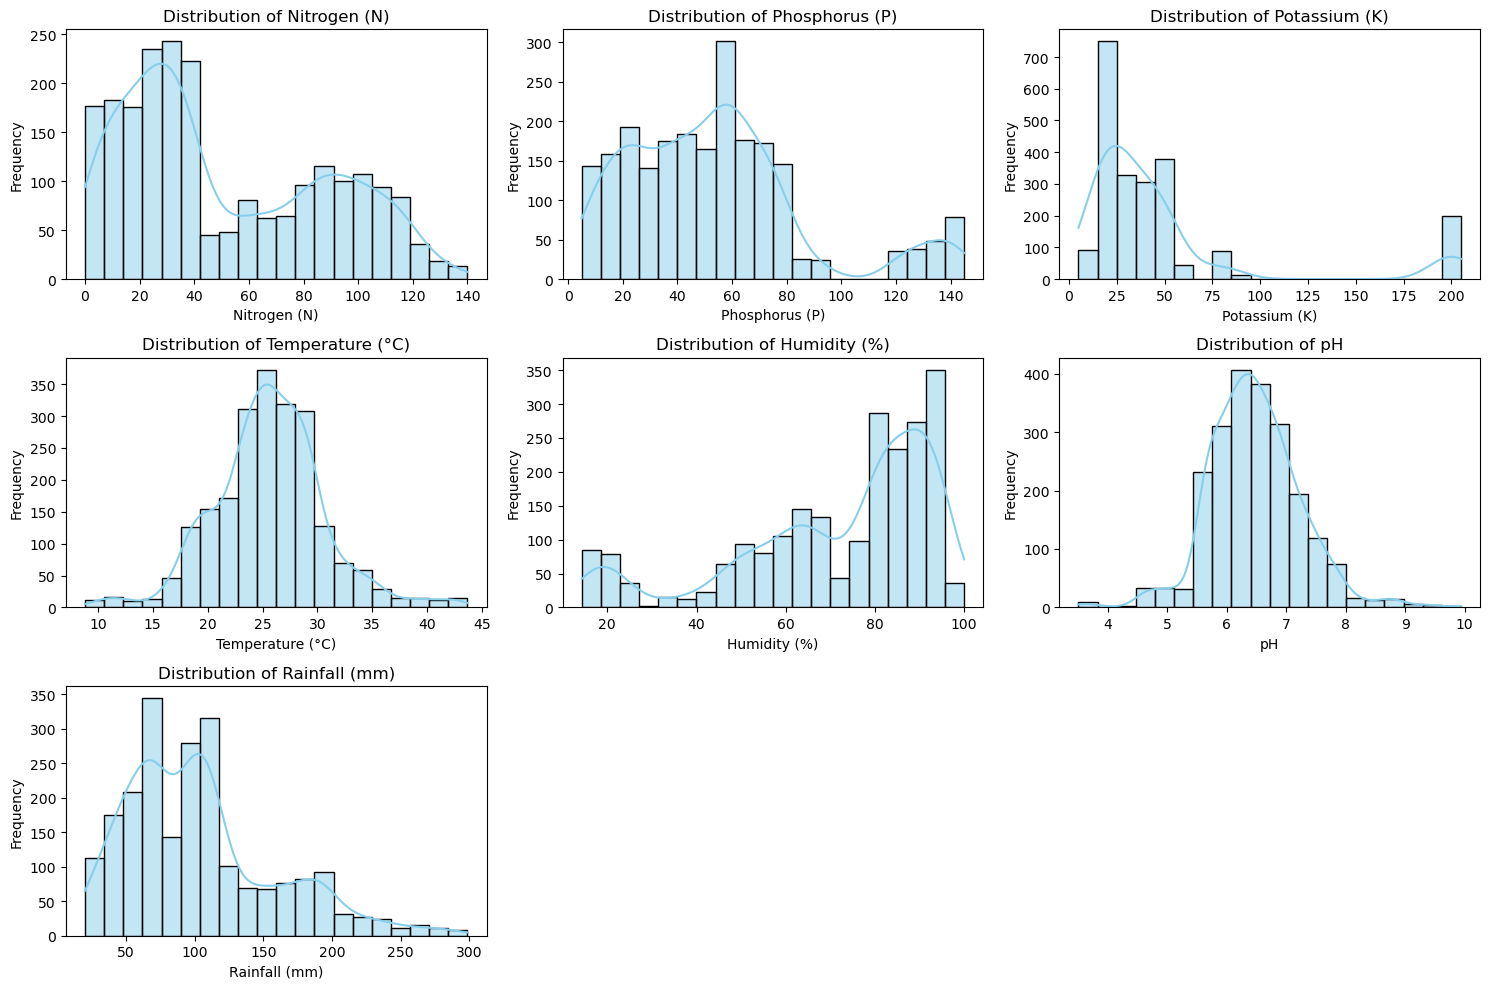

In [10]:
# Plot histograms for all numeric features (N, P, K, temperature, humidity, pH, rainfall) using Seaborn
# Subplot grid displays all distributions in one figure for a comprehensive view
plt.figure(figsize=(15, 10))  # Larger figure to fit 7 subplots comfortably
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']  # List of feature names
feature_titles = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)', 'Temperature (°C)', 
                  'Humidity (%)', 'pH', 'Rainfall (mm)']  # Descriptive titles

for i, (col, title) in enumerate(zip(feature_cols, feature_titles), 1):
    plt.subplot(3, 3, i)  # 3 rows, 3 columns grid; i is the subplot position
    sns.histplot(crop[col], bins=20, color='skyblue', kde=True)
    plt.title(f'Distribution of {title}', fontsize=12)
    plt.xlabel(title, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()  # Adjusts spacing between subplots for clarity
plt.show()

## Visualization - Correlation Matrix Heatmap with Seaborn

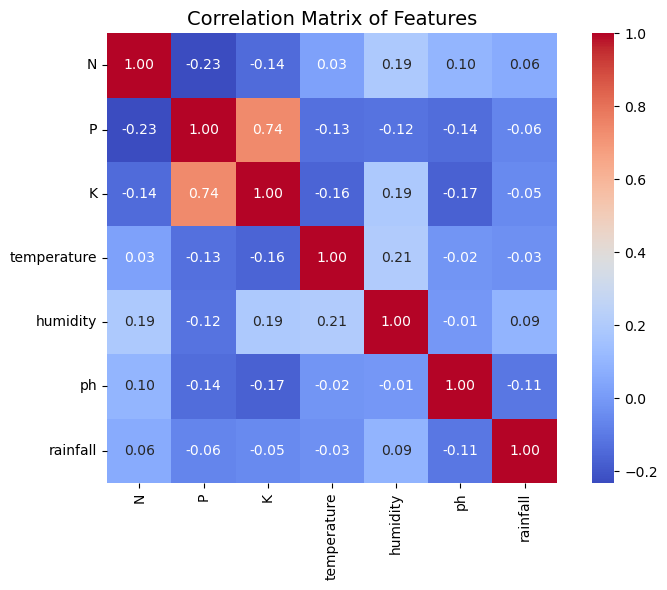

In [11]:
# Create a correlation heatmap with Seaborn to show feature relationships
# annot=True displays correlation values; cmap='coolwarm' enhances visual appeal
corr_matrix = crop.drop('label', axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()

## Prepare Features and Target

In [12]:
# Separate features (X) and target variable (y)
# X: Input variables for prediction; y: Crop labels to predict
X = crop.drop('label', axis=1)
y = crop['label']

## Split Data into Train and Test Sets

In [13]:
# Split data: 80% for training, 20% for testing
# random_state=42 ensures consistent splits across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale the Features

In [14]:
# Scale features to standardize them (mean=0, variance=1)
# Improves model performance by normalizing feature scales
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit scaler to training data and transform
X_test = scaler.transform(X_test)        # Apply same transformation to test data
scaler  # Display scaler object (optional)

StandardScaler()

## Train Random Forest Model

In [15]:
# Train a Random Forest Classifier with specific hyperparameters
# n_estimators=200: Builds 200 trees; criterion="entropy": Uses entropy for splits; max_depth=20: Limits tree depth
rfc = RandomForestClassifier(n_estimators=200, criterion="entropy", max_depth=20, random_state=42)
rfc.fit(X_train, y_train)  # Train the model on scaled training data

RandomForestClassifier(criterion='entropy', max_depth=20, n_estimators=200,
                       random_state=42)

## Make Predictions and Evaluate

In [16]:
# Predict test set labels and calculate accuracy
# Accuracy measures how often predictions match actual labels
y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Model Accuracy: {accuracy * 100:.2f}%")

Initial Model Accuracy: 99.32%


## Hyperparameter Tuning with GridSearchCV

In [17]:
# Optimize Random Forest hyperparameters using GridSearchCV
# Tests combinations to find the best settings; cv=5 means 5-fold cross-validation
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],         # Number of trees
    'criterion': ['gini', 'entropy'],   # Split quality metric
    'max_depth': [10, 20, None],        # Max tree depth (None = unlimited)
    'min_samples_split': [2, 5],        # Min samples to split a node
    'min_samples_leaf': [1, 2]          # Min samples in a leaf
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           verbose=1, 
                           n_jobs=-1)  # Use all CPU cores for speed
grid_search.fit(X_train, y_train)

print("Best Hyperparameters Found:", grid_search.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters Found: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## Train with Best Parameters and Evaluate

In [18]:
# Train the model with the best hyperparameters from GridSearchCV
best_rfc = grid_search.best_estimator_
best_rfc.fit(X_train, y_train)

# Predict and evaluate accuracy
y_pred = best_rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized Model Accuracy: {accuracy * 100:.2f}%")

Optimized Model Accuracy: 99.32%


## Visualization - Predicted vs Actual Counts

Predicted Crop Counts:
            Crop  Count       Type
0       coconut     27  Predicted
1      chickpea     26  Predicted
2          jute     25  Predicted
3        papaya     23  Predicted
4         apple     23  Predicted
5    pigeonpeas     23  Predicted
6     mothbeans     23  Predicted
7   pomegranate     23  Predicted
8         maize     21  Predicted
9        banana     21  Predicted
10    blackgram     20  Predicted
11  kidneybeans     20  Predicted
12   watermelon     19  Predicted
13     mungbean     19  Predicted
14        mango     19  Predicted
15       coffee     17  Predicted
16         rice     17  Predicted
17       cotton     17  Predicted
18    muskmelon     17  Predicted
19       orange     14  Predicted
20       grapes     14  Predicted
21       lentil     12  Predicted

Actual Crop Counts:
           label  Count    Type
0       coconut     27  Actual
1      chickpea     26  Actual
2     mothbeans     24  Actual
3          jute     23  Actual
4        papaya  

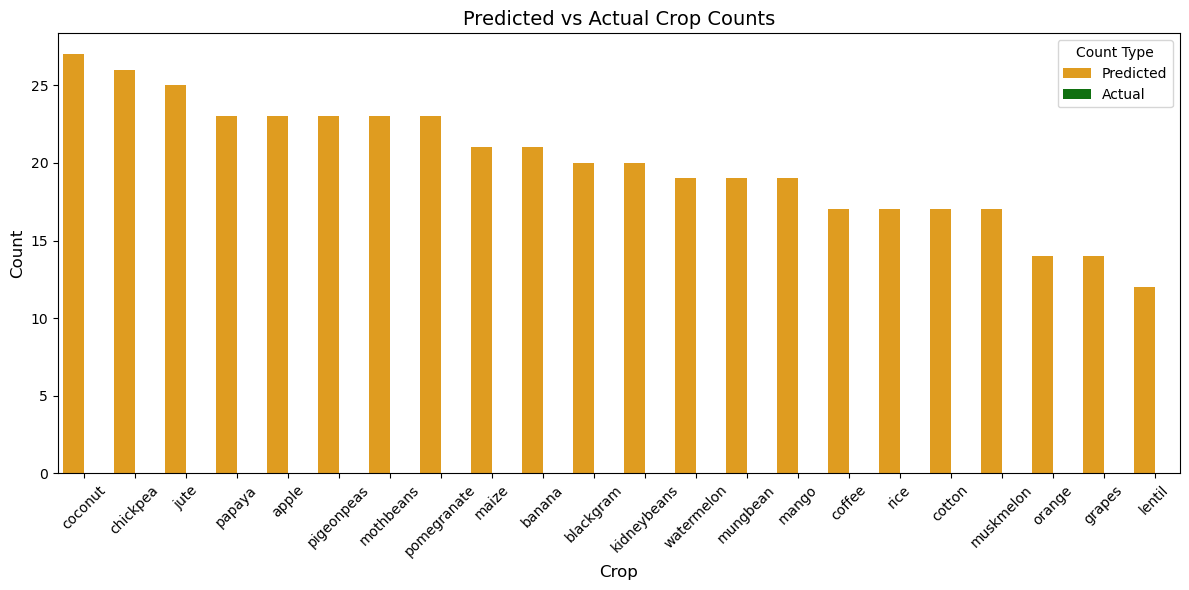

In [19]:
# Compare predicted vs actual crop counts using Seaborn’s barplot
# hue distinguishes between predicted (salmon) and actual (lightblue) counts
pred_counts = pd.Series(y_pred).value_counts().reset_index().rename(columns={'index': 'Crop', 'count': 'Count'})
pred_counts['Type'] = 'Predicted'
true_counts = pd.Series(y_test).value_counts().reset_index().rename(columns={'index': 'Crop', 'count': 'Count'})
true_counts['Type'] = 'Actual'
combined_counts = pd.concat([pred_counts, true_counts])

# Print counts for verification
print("Predicted Crop Counts:\n", pred_counts)
print("\nActual Crop Counts:\n", true_counts)

# Plot with Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Crop', y='Count', hue='Type', data=combined_counts, palette=['orange', 'green'], dodge=True)
plt.title('Predicted vs Actual Crop Counts', fontsize=14)
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Count Type', fontsize=10)
plt.tight_layout()
plt.show()

## Saving the Model and Scaler

In [20]:
# Save the trained model and scaler to files
# Allows reuse without retraining
import joblib

joblib.dump(best_rfc, './models/crop_classifier.pkl')
joblib.dump(scaler, './models/scaler.pkl')
print("Success: Model and scaler saved to './models/'!")

Success: Model and scaler saved to './models/'!


## Prediction Function and Example

In [21]:
# Load saved model and scaler, then predict crop for new input
# Function takes user input, scales it, and returns a crop recommendation
model = joblib.load('./models/crop_classifier.pkl')
scaler = joblib.load('./models/scaler.pkl')

def recommend_crop(input_data, model, scaler):
    features = np.array([[input_data['N'], input_data['P'], input_data['K'], 
                          input_data['temperature'], input_data['humidity'], 
                          input_data['ph'], input_data['rainfall']]])
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)[0]
    return prediction

# Test with example input
user_input = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.8,
    'humidity': 82.0,
    'ph': 6.5,
    'rainfall': 202.9
}

predicted_crop = recommend_crop(user_input, model, scaler)
print(f"Recommended Crop for Your Conditions: {predicted_crop}")

Recommended Crop for Your Conditions: rice


## Feature Importance Visualization with Seaborn

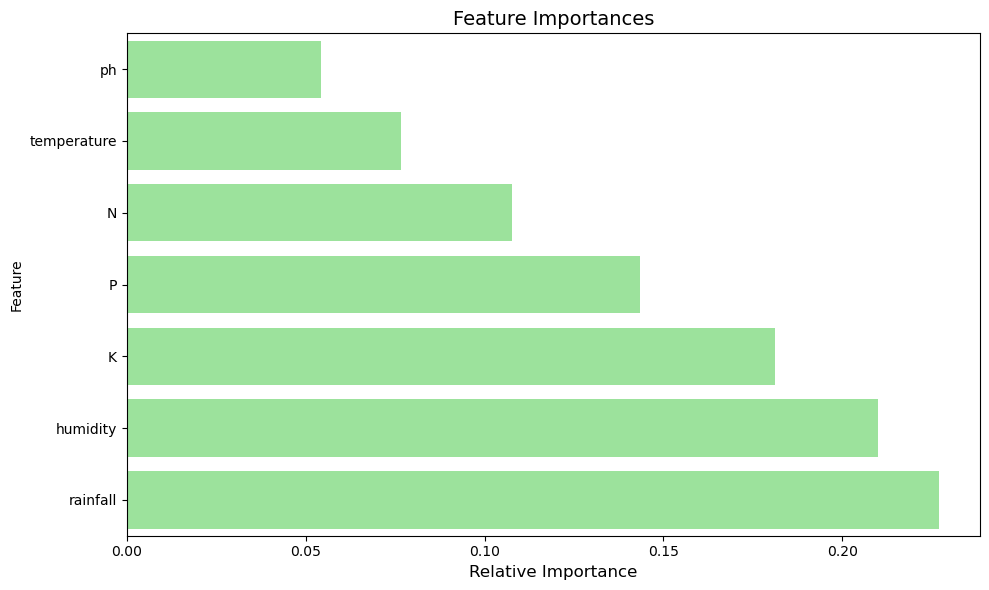

In [22]:
# Visualize feature importance with Seaborn’s barplot
# Shows which features most influence crop predictions
feature_names = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
importances = best_rfc.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance')

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, color='lightgreen')
plt.title('Feature Importances', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.tight_layout()
plt.show()